# Comparison between synthetic and observed data

## Import libraries and functions

In [1]:
import rain_generator as rg
import pandas as pd
import glob
import os
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from math import ceil
from sklearn.metrics import r2_score

def plot_correl(x,y,xtitle,ytitle,salida_pdf,ticks_fix=[]):
  # r Pearson
  #r=np.corrcoef(x,y)
  # r2 Coeficiente de determinación
  r2=r2_score(x,y)
  redondealen=1
  maximo=np.max([np.max(x),np.max(y)])
  if len(ticks_fix)==0:
      lensq=ceil(maximo/redondealen)*redondealen
  else:
      lensq=np.max(ticks_fix)
      minval=np.min(ticks_fix)
  plt.figure(figsize=(5, 5))
  #plt.axis('square')
  plt.xlim([minval,lensq])
  plt.ylim([minval,lensq])
  plt.gca().set_xbound(minval, lensq)
  plt.gca().set_ybound(minval, lensq)
  plt.gca().set_aspect('equal')
  if len(ticks_fix)>0:
    plt.xticks(ticks_fix)
    plt.yticks(ticks_fix)
  #plt.gca().set_box_aspect(1)
  box_style=dict(boxstyle='round', facecolor='white', alpha=1)
  plt.rc('font', size=14)
  sepx=0.65
  sepy=0.1
  plt.text(sepx * (lensq - minval) + minval, sepy * (lensq-minval) + minval, "r$^2$="+str(round(r2,4)),{'weight':'heavy','size':14},bbox=box_style)
  plt.grid(color='gray', linestyle='--', linewidth=0.5)
  plt.ylabel(ytitle)
  plt.xlabel(xtitle)
  # Línea de tendencia
  z = np.polyfit(x, y, 1)
  p = np.poly1d(z)
  plt.plot(x,p(x),"r--")
  # Gráficar los puntos
  plt.scatter(x,y,color="blue")
  plt.savefig(salida_pdf,bbox_inches='tight')
  plt.clf()
  
def calcula_ticks(valor_mínimo,valor_máximo,espacios):
  longitud=valor_máximo-valor_mínimo
  tick=np.round(longitud/espacios,2)
  return np.linspace(valor_mínimo,valor_mínimo+tick*espacios,espacios+1)

## Random generator and comparison with observed data

Open table with daily precipitation and set time period

In [2]:
path_clima="../../data/"
path_output="../../generator/comparison/"
ai=1951
af=2020
estaciones=["11020","11025","11035","11036","11040","11045","11049","11055","11095","11099","11153","11157","11159","14157","14369"]
fechas=["01/01/"+str(ai),"01/01/"+str(af+1),"%d/%m/%Y","Fecha"]
precipitaciones=rg.pd.read_csv(path_clima+"1PRECIPITACION.csv",na_values="Nulo")
pdb=rg.filtra_ts(precipitaciones,fechas)
pdb=pdb[estaciones]

Calculate probability parameters

In [3]:
st="11020"
lluvia_total=rg.dist_discreta_fr_day(pdb,st)
prob_lluvia_total=lluvia_total[1]/(lluvia_total[0]+lluvia_total[1])

modo="alpha5lluvia"
dist=[rg.stats.beta,"beta"]
tolerancia=32
delta=10
#param_max=12
ai=1951
af=2020
st="11020"
lim_min=0
lim_max=1000
parametros_prob=rg.tabla_prob(
    pdb,
    ai,
    af,
    delta,
    tolerancia,
    dist,
    modo,
    lim_min,
    lim_min)

/mnt/0577af72-516e-4803-acc8-86e40b0df9de/rocky9/.virtualenvs/pyDCTA312/lib64/python3.12/site-packages/scipy/stats/_continuous_distns.py:795: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/mnt/0577af72-516e-4803-acc8-86e40b0df9de/rocky9/.virtualenvs/pyDCTA312/lib64/python3.12/site-packages/scipy/stats/_continuous_distns.py:795: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/mnt/0577af72-516e-4803-acc8-86e40b0df9de/rocky9/.virtualenvs/pyDCTA312/lib64/python3.12/site-packages/scipy/stats/_continuous_distns.py:795: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/mnt/0577af72-516e-4803-acc8-86e40b0df9de/rocky9/.virtualenvs/pyDCTA312/lib64/python3.12/site-packages/scipy/stats/_continuous_distns.py:795: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b 

Comparison between synthetic data and observed data

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

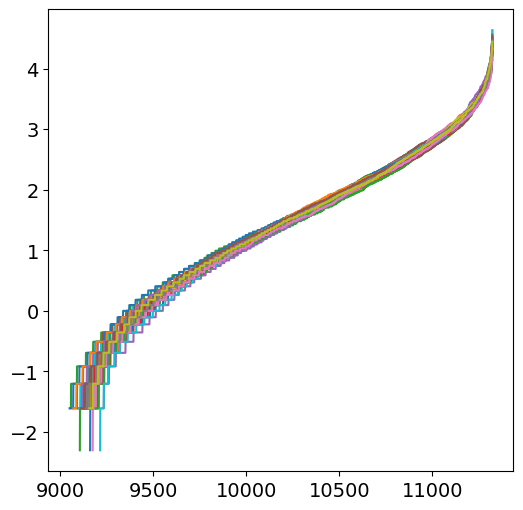

In [4]:
ai=1980
af=2010
fechas=["01/01/"+str(ai),"01/01/"+str(af+1),"%d/%m/%Y","Fecha"]
pdb_filt=rg.filtra_ts(precipitaciones,fechas)

iterations=100
for st in list(["11020","11095","11040","11036","11025"]):
  for factor_prob in [0.75,1.0,1.25]:
    for param_tipo in ["Mínimo","Promedio","Máximo"]:
      plt.clf()
      plt.figure(figsize=(6, 6))
      for i in range(iterations):
        serie_sintetica=rg.input_random(ai,af,[st],parametros_prob[0],param_tipo,prob_lluvia_total*factor_prob,modo)
        sin_ord=serie_sintetica.sort_values(by=st)
        sin_ord.index=range(len(sin_ord))
        obs_ord=pd.DataFrame(pdb_filt[st]).sort_values(by=st)
        obs_ord.index=range(len(obs_ord))
        # Y0 es el log(Pr_observadas) descartando los ceros.
        Y0=obs_ord
        Y0[Y0==0]=np.nan
        Y0=Y0.dropna()
        Y0=np.log(Y0)
        # Y1 es el log(Pr_sintéticas) descartando los ceros.
        Y1=sin_ord
        Y1[Y1==0]=np.nan
        Y1=Y1.dropna()
        Y1=np.log(Y1)
        plt.plot(Y1[st].index,Y1.values)
      plt.plot(Y0[st].index,Y0.values,label="Observed precipitation",color="blue")
      plt.legend()
      plt.rc('font', size=14)   
      plt.grid(color='gray', linestyle='--', linewidth=0.5)
      plt.xlabel("Day")
      plt.ylabel("Day precipitation logarithm")
      for fileformat in ["pdf","svg","eps"]:
        plt.savefig(path_output+fileformat+"/"+st+param_tipo+"fprob"+str(factor_prob)+"."+fileformat,bbox_inches='tight')
        #plt.show()

## Calculate correlations

In [3]:
path_output="../../generator/cor/"

st="11095"
ai=1951
af=2020
delta_t=10
tolerancia_nan=32
modo="alpha5lluvia"
max_pr=140
fix_ticks=rg.calcula_ticks(130,9,5)
distributions=[[rg.stats.beta,"beta"],
               [rg.stats.norm,"norm"],
               [rg.stats.expon,"expon"],
               [rg.stats.gumbel_r,"gumbel_r"],
               [rg.stats.gamma,"gamma"]]
for distrib in distributions:
    for st in estaciones:
        for fileformat in ["pdf","svg","eps"]:
            rg.plot_dist_par(pdb,st,ai,af,delta_t,tolerancia_nan,distrib,modo,path_output+fileformat+"/",fileformat,fix_ticks)

/mnt/0577af72-516e-4803-acc8-86e40b0df9de/rocky9/.virtualenvs/pyDCTA312/lib64/python3.12/site-packages/scipy/stats/_continuous_distns.py:795: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/mnt/646723B3445A5D3B/DCTA/GIT/robust-figures/code/generator/rain_generator.py:538: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(5, 5))
/mnt/0577af72-516e-4803-acc8-86e40b0df9de/rocky9/.virtualenvs/pyDCTA312/lib64/python3.12/site-packages/scipy/stats/_continuous_distns.py:795: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/mnt/0577af72-516e-4803-acc8-86e40b0df9de/rocky9/.virtualenvs/py

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

...

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>